**Study of Activation Functions in Artificial Neural Networks.**

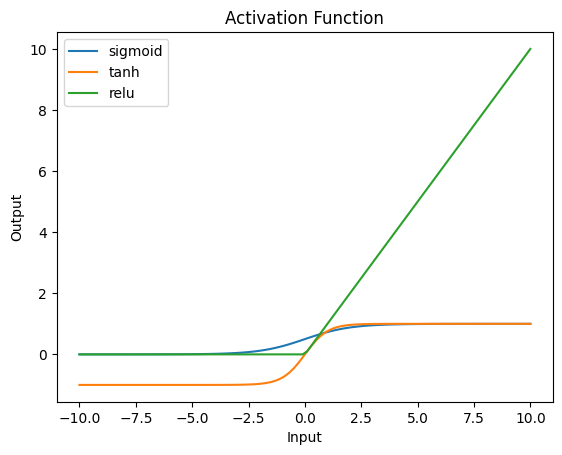

In [1]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-10, 10, 100)
sigmoid = 1/(1+np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0,x)
plt.plot(x,sigmoid,label='sigmoid')
plt.plot(x,tanh,label='tanh')
plt.plot(x,relu,label='relu')
plt.title('Activation Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.legend()
plt.show()

**Customer Churn Prediction Using an Activation Function.**

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Sample customer dataset
data = {
    'Age': [
        22, 45, 30, 52, 28, 40, 35, 60, 25, 48,
        33, 55, 29, 42, 38, 50, 24, 57, 31, 46
    ],

    'MonthlyCharges': [
        30, 80, 45, 90, 35, 70, 55, 95, 40, 85,
        50, 88, 42, 75, 60, 82, 32, 92, 48, 78
    ],

    'Tenure': [
        2, 36, 12, 48, 5, 30, 18, 60, 7, 42,
        20, 50, 10, 32, 25, 45, 3, 55, 15, 38
    ],

    'SupportCalls': [
        5, 1, 4, 0, 6, 2, 3, 0, 5, 1,
        4, 0, 6, 2, 3, 1, 7, 0, 4, 2
    ],

    'Churn': [
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 0, 0, 1, 0, 1, 0
    ]
}

# Convert dictionary to DataFrame
df = pd.DataFrame(data)

# Input and output
X = df[['Age', 'MonthlyCharges', 'Tenure', 'SupportCalls']]
y = df['Churn']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Scale the input data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create neural network
model = Sequential([
    Dense(8, activation='relu', input_shape=(4,)),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(
    X_train,
    y_train,
    epochs = 100,
    verbose = 0
)
# Prediction
probability = model.predict(X_test)
prediction = (probability >= 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(y_test, prediction)

print("Predicted values:")
print(prediction.flatten())

print("Actual values:")
print(y_test.values)

print("Accuracy:", accuracy)

print("Confusion Matrix:")
print(confusion_matrix(y_test, prediction))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted values:
[1 0 0 0 1]
Actual values:
[1 0 0 0 1]
Accuracy: 1.0
Confusion Matrix:
[[3 0]
 [0 2]]
